In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("/content/heart.csv")

In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [11]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
df.duplicated().sum()

np.int64(1)

In [15]:
df[df.duplicated(keep=False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [16]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

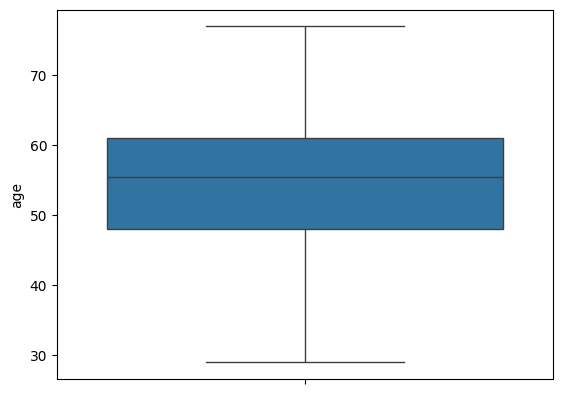

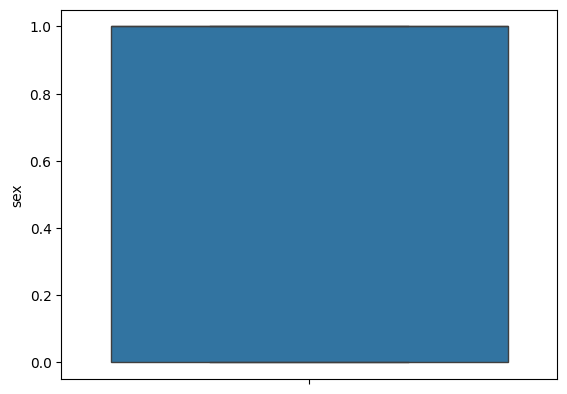

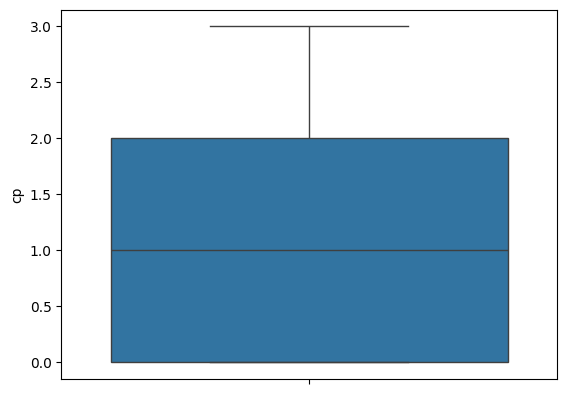

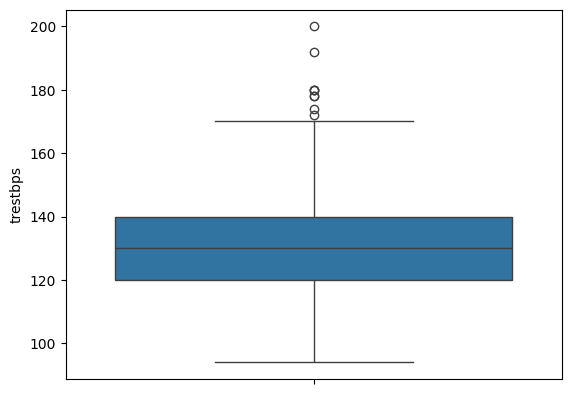

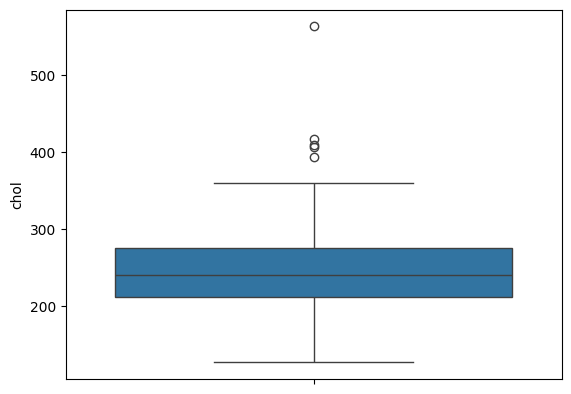

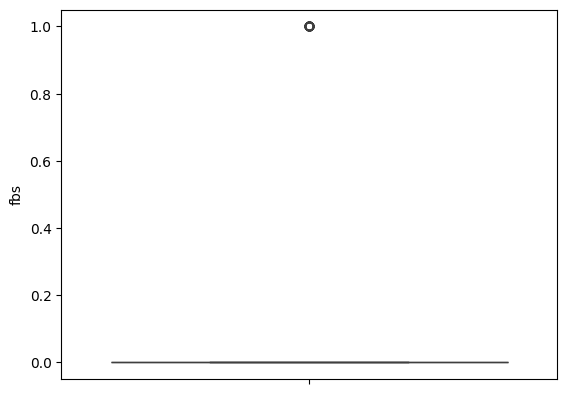

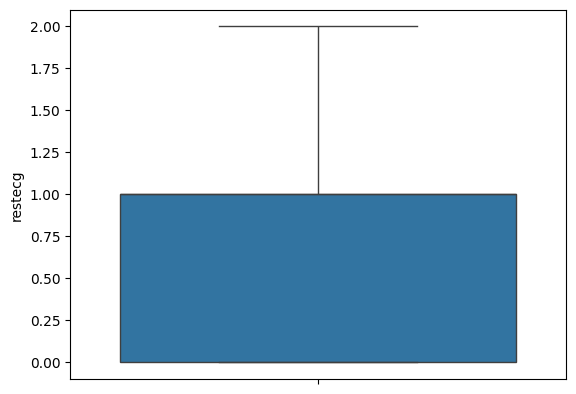

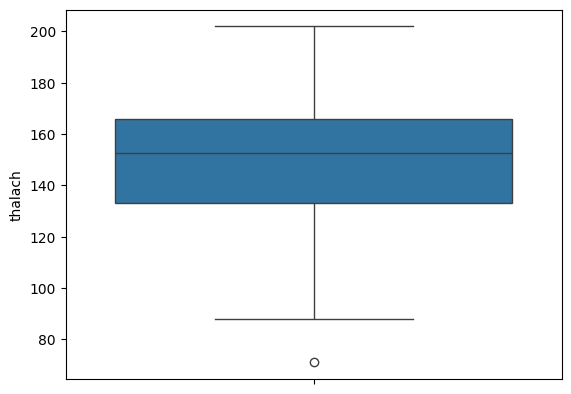

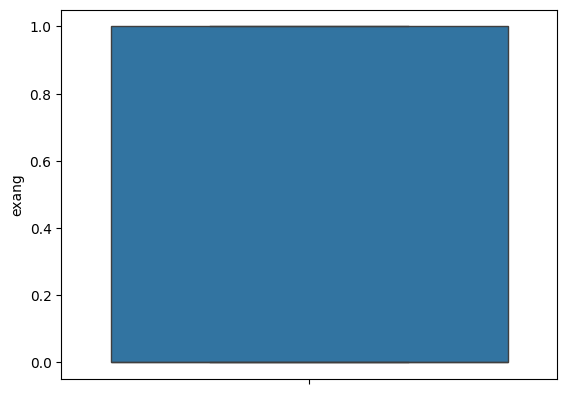

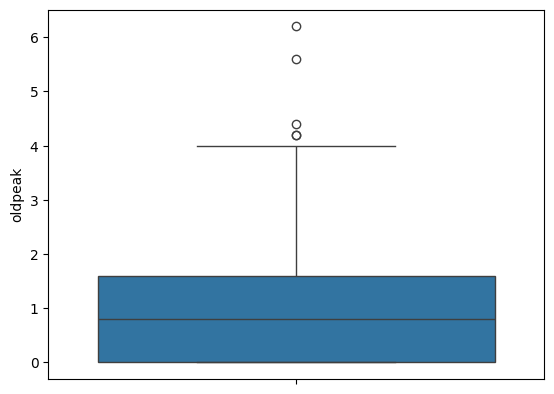

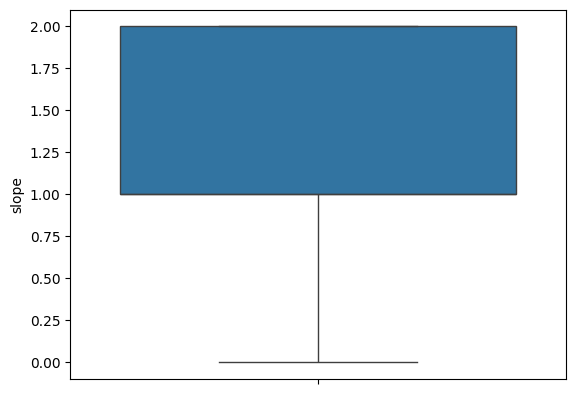

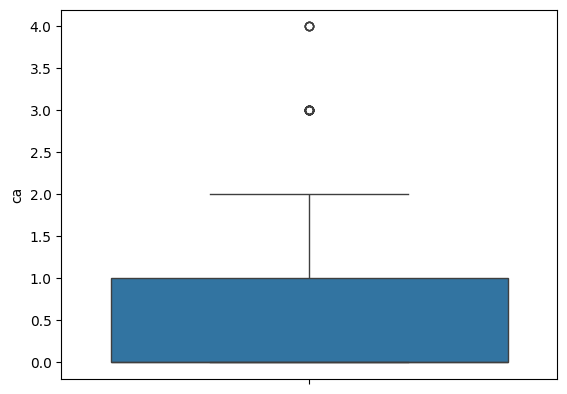

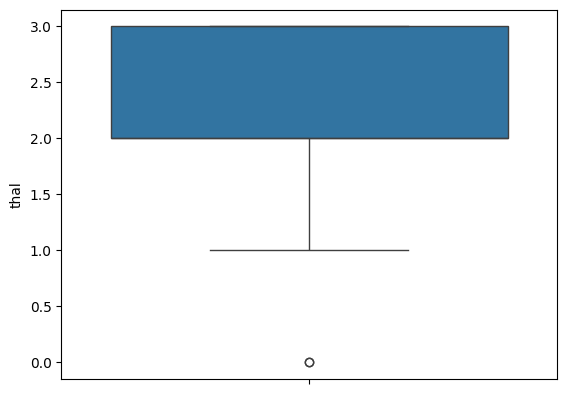

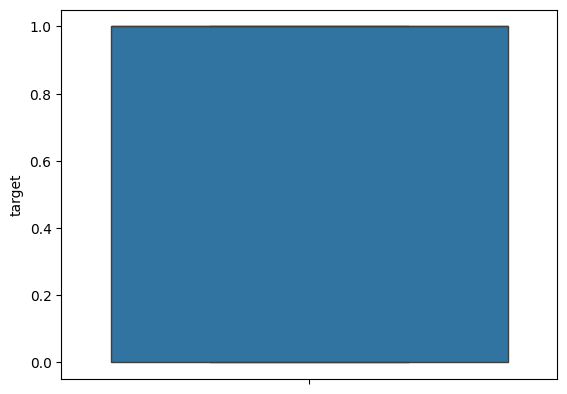

In [23]:
col = df.columns

for col_name in col:
    if df[col_name].dtype != 'object':
        sns.boxplot(df[col_name])
        plt.show()

In [25]:
outliers_col = [ 'trestbps', 'chol','fbs', 'thalach', 'oldpeak','ca','thal']
for i in outliers_col:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr
    df[i] = np.where(df[i] > upper_limit, upper_limit, np.where(df[i] < lower_limit, lower_limit, df[i]))
    print("Outliers removed successfully")
    print("New shape:", df.shape)



Outliers removed successfully
New shape: (302, 14)
Outliers removed successfully
New shape: (302, 14)
Outliers removed successfully
New shape: (302, 14)
Outliers removed successfully
New shape: (302, 14)
Outliers removed successfully
New shape: (302, 14)
Outliers removed successfully
New shape: (302, 14)
Outliers removed successfully
New shape: (302, 14)


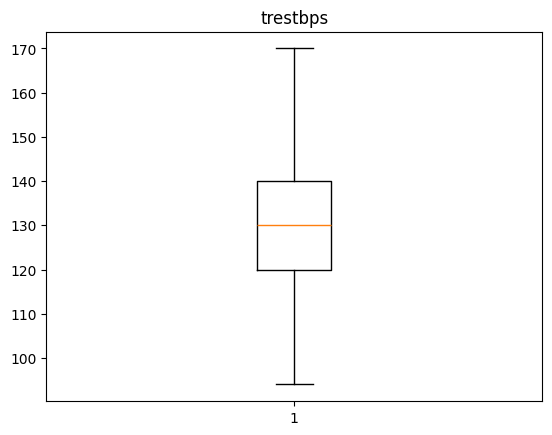

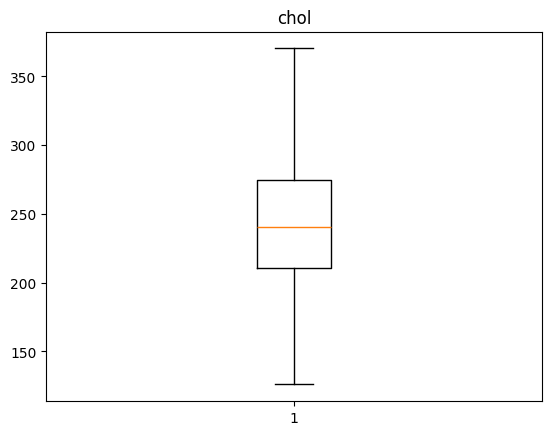

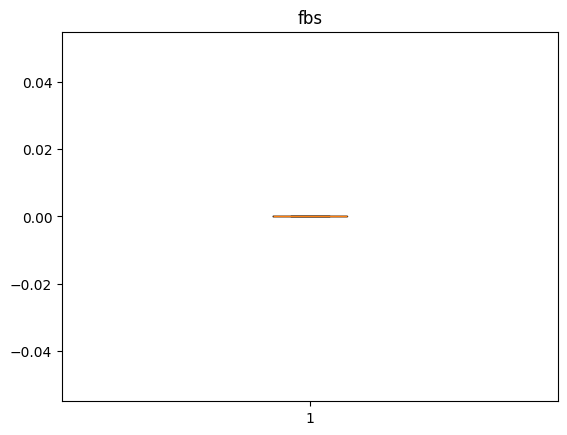

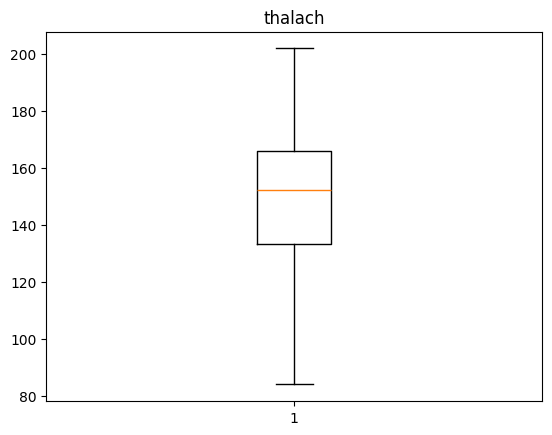

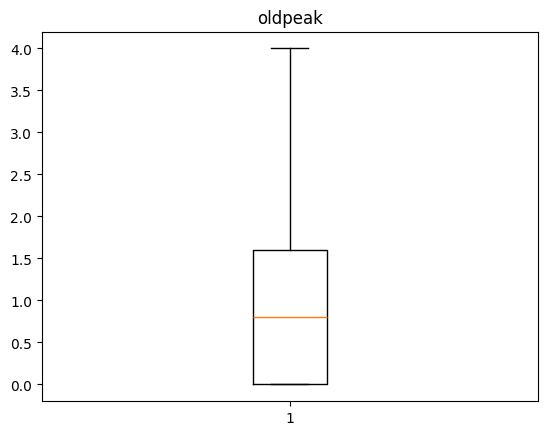

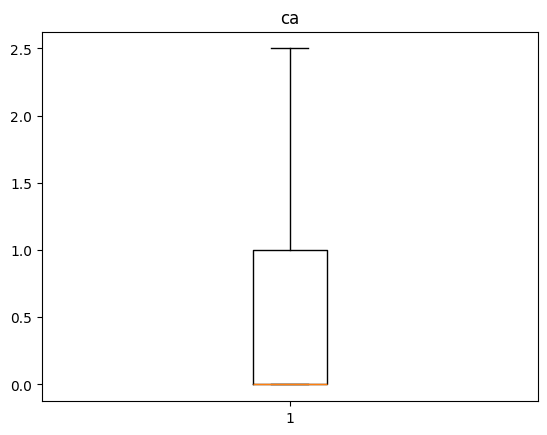

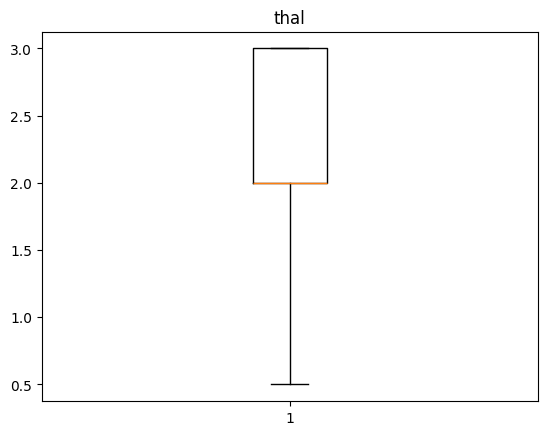

In [28]:
outliers_col = [ 'trestbps', 'chol','fbs', 'thalach', 'oldpeak','ca','thal']
for i in outliers_col:
    plt.figure()
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()


In [44]:
x = df.iloc[:,0:13]

x


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145.0,233.0,0.0,0,150.0,0,2.3,0,0.0,1.0
1,37,1,2,130.0,250.0,0.0,1,187.0,0,3.5,0,0.0,2.0
2,41,0,1,130.0,204.0,0.0,0,172.0,0,1.4,2,0.0,2.0
3,56,1,1,120.0,236.0,0.0,1,178.0,0,0.8,2,0.0,2.0
4,57,0,0,120.0,354.0,0.0,1,163.0,1,0.6,2,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140.0,241.0,0.0,1,123.0,1,0.2,1,0.0,3.0
299,45,1,3,110.0,264.0,0.0,1,132.0,0,1.2,1,0.0,3.0
300,68,1,0,144.0,193.0,0.0,1,141.0,0,3.4,1,2.0,3.0
301,57,1,0,130.0,131.0,0.0,1,115.0,1,1.2,1,1.0,3.0


In [46]:
y = df.iloc[:,-1]
y

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [47]:
from sklearn.model_selection import train_test_split


In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [51]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
74,43,0,2,122.0,213.0,0.0,1,165.0,0,0.2,1,0.0,2.0
153,66,0,2,146.0,278.0,0.0,0,152.0,0,0.0,1,1.0,2.0
64,58,1,2,140.0,211.0,0.0,0,165.0,0,0.0,2,0.0,2.0
296,63,0,0,124.0,197.0,0.0,1,136.0,1,0.0,1,0.0,2.0
288,57,1,0,110.0,335.0,0.0,1,143.0,1,3.0,1,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,62,0,0,138.0,294.0,0.0,1,106.0,0,1.9,1,2.5,2.0
193,60,1,0,145.0,282.0,0.0,0,142.0,1,2.8,1,2.0,3.0
117,56,1,3,120.0,193.0,0.0,0,162.0,0,1.9,1,0.0,3.0
47,47,1,2,138.0,257.0,0.0,0,156.0,0,0.0,2,0.0,2.0


In [53]:
from sklearn.preprocessing import MinMaxScaler

In [54]:
mms=MinMaxScaler()

In [55]:
mms.fit(x_train)

MinMaxScaler()

In [57]:
x_train_scale=mms.transform(x_train)
x_train_scale

array([[0.29166667, 0.        , 0.66666667, ..., 0.5       , 0.        ,
        0.6       ],
       [0.77083333, 0.        , 0.66666667, ..., 0.5       , 0.4       ,
        0.6       ],
       [0.60416667, 1.        , 0.66666667, ..., 1.        , 0.        ,
        0.6       ],
       ...,
       [0.5625    , 1.        , 1.        , ..., 0.5       , 0.        ,
        1.        ],
       [0.375     , 1.        , 0.66666667, ..., 1.        , 0.        ,
        0.6       ],
       [0.60416667, 1.        , 0.66666667, ..., 1.        , 0.8       ,
        1.        ]])

In [58]:
x_test_scale=mms.transform(x_test)
x_test_scale

array([[ 0.6875    ,  1.        ,  0.33333333,  0.34210526,  0.62663185,
         0.        ,  0.        ,  0.16012725,  0.        ,  0.35      ,
         0.5       ,  0.4       ,  1.        ],
       [ 0.72916667,  1.        ,  1.        ,  1.        ,  0.40104439,
         0.        ,  0.        ,  0.60127253,  0.        ,  0.15      ,
         0.5       ,  0.        ,  1.        ],
       [ 0.72916667,  1.        ,  0.66666667,  0.40789474,  0.74360313,
         0.        ,  0.5       ,  0.39766702,  1.        ,  0.45      ,
         0.5       ,  0.        ,  1.        ],
       [ 0.60416667,  1.        ,  0.        ,  0.73684211,  0.58067885,
         0.        ,  0.        ,  0.22799576,  1.        ,  0.2       ,
         1.        ,  0.        ,  1.        ],
       [ 0.6875    ,  1.        ,  0.66666667,  0.47368421,  0.41775457,
         0.        ,  0.5       ,  0.52492047,  0.        ,  0.45      ,
         0.5       ,  1.        ,  1.        ],
       [ 0.5625    ,  0.      

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression



In [75]:
# X = independent variables
# y = target variable

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)



In [76]:
# Min-Max Scaling
scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [77]:
# Model fitting
model = LogisticRegression()

model.fit(x_train_scaled, y_train)



LogisticRegression()

In [78]:
# Prediction
y_pred = model.predict(x_test_scaled)

In [80]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy %:", accuracy * 100)

Accuracy: 0.8360655737704918
Accuracy %: 83.60655737704919
